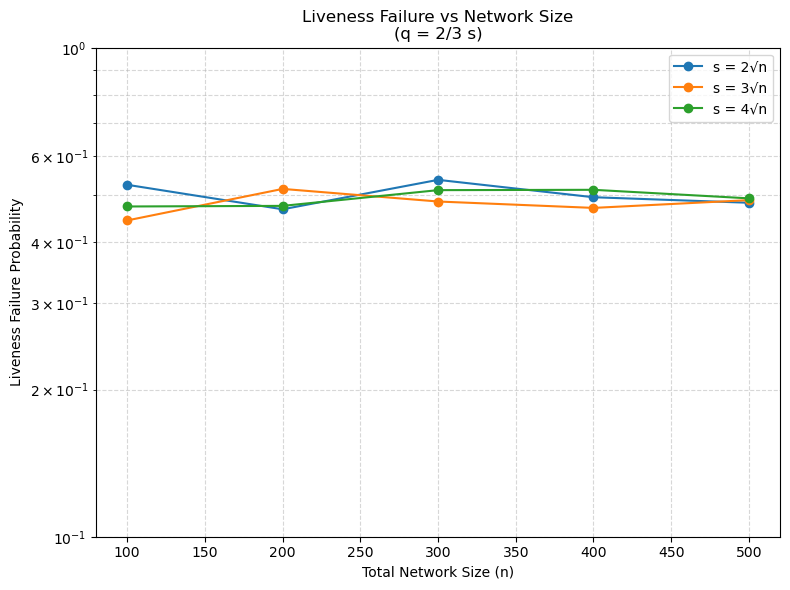

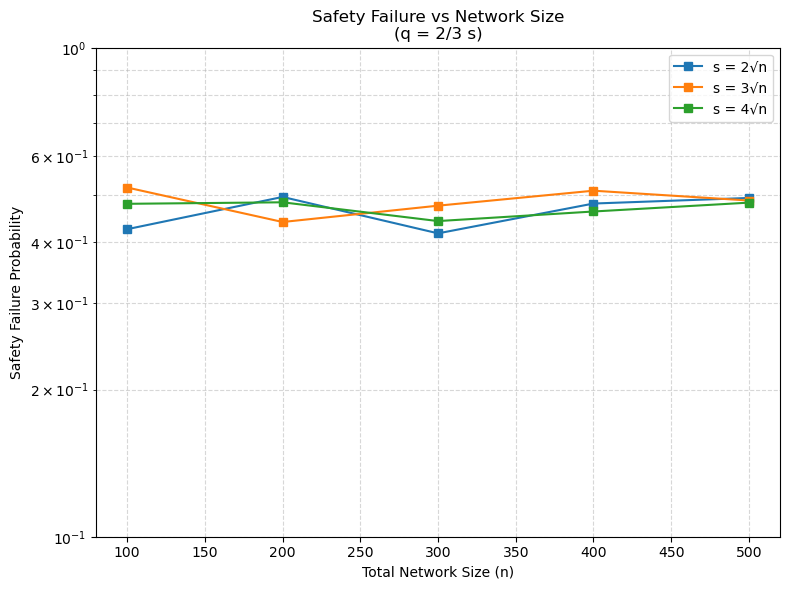

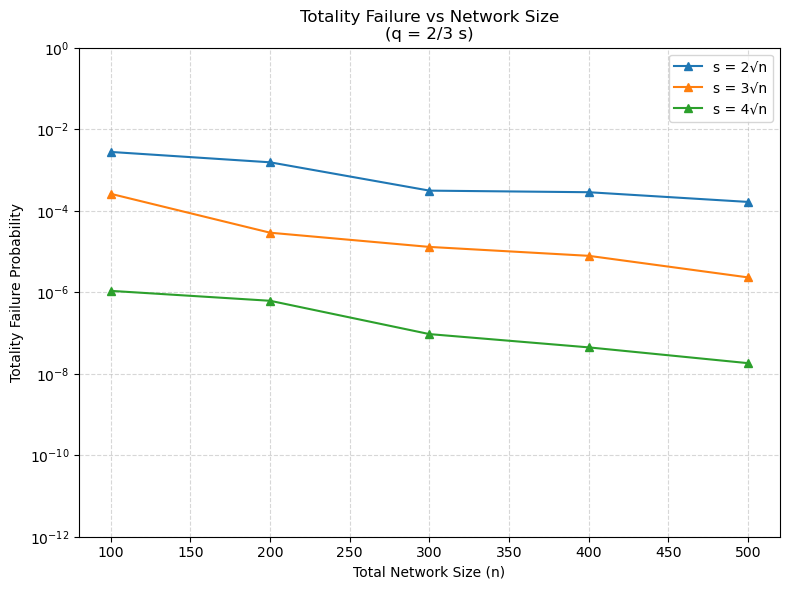

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# --- 1. Original Binomial Formulas ---
def calc_eps_live(n, f, p, q):
    if q > n - f: return 1.0 
    return binom.cdf(q - 1, n - f, p)

def calc_eps_totality(n, f, p, q):
    return binom.sf(q - 1, f, p)

def calc_eps_safe(n, f, p, q):
    eps_safe = 0.0
    for i in range(f + 1):  
        prob_B = binom.pmf(i, f, p)
        min_j = max(0, 2*q - 2*i) 
        if min_j <= n - f:
            prob_H = binom.sf(min_j - 1, n - f, p)
            eps_safe += prob_B * prob_H
    return eps_safe

# --- 2. Professor's Parameters ---
n_values = [100, 200, 300, 400, 500]
constants = [2, 3, 4] # The 'c' in s = c * sqrt(n)

# ==========================================
# GRAPH 1: LIVENESS 
# ==========================================
plt.figure(figsize=(8, 6))
for c in constants:
    probs = []
    for n in n_values:
        f = int((n - 1) / 3)         # Maximum Byzantine nodes
        s_expected = c * np.sqrt(n)  # s = 2*sqrt(n), 3*sqrt(n), or 4*sqrt(n)
        p = s_expected / n           # Probability of joining the sample
        q = int(np.ceil((2 * s_expected) / 3)) # q = 2/3 of expected sample
        
        probs.append(calc_eps_live(n, f, p, q))
    
    plt.plot(n_values, probs, label=f's = {c}√n', marker='o')

plt.yscale('log')
plt.ylim(1e-1, 1) 
plt.xlabel('Total Network Size (n)')
plt.ylabel('Liveness Failure Probability')
plt.title('Liveness Failure vs Network Size\n(q = 2/3 s)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# GRAPH 2: SAFETY
# ==========================================
plt.figure(figsize=(8, 6))
for c in constants:
    probs = []
    for n in n_values:
        f = int((n - 1) / 3)         
        s_expected = c * np.sqrt(n)  
        p = s_expected / n           
        q = int(np.ceil((2 * s_expected) / 3))
        
        probs.append(calc_eps_safe(n, f, p, q))
    
    plt.plot(n_values, probs, label=f's = {c}√n', marker='s')

plt.yscale('log')
plt.ylim(1e-1, 1)
plt.xlabel('Total Network Size (n)')
plt.ylabel('Safety Failure Probability')
plt.title('Safety Failure vs Network Size\n(q = 2/3 s)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# GRAPH 3: TOTALITY
# ==========================================
plt.figure(figsize=(8, 6))
for c in constants:
    probs = []
    for n in n_values:
        f = int((n - 1) / 3)         
        s_expected = c * np.sqrt(n)  
        p = s_expected / n           
        q = int(np.ceil((2 * s_expected) / 3))
        
        probs.append(calc_eps_totality(n, f, p, q))
    
    plt.plot(n_values, probs, label=f's = {c}√n', marker='^')

plt.yscale('log')
plt.ylim(1e-12, 1)
plt.xlabel('Total Network Size (n)')
plt.ylabel('Totality Failure Probability')
plt.title('Totality Failure vs Network Size\n(q = 2/3 s)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()